In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

df = pd.read_csv("/kaggle/input/datasets/gellanromanygeorge/irrigation-dataset/train (1).csv")
dftest = pd.read_csv("/kaggle/input/datasets/gellanromanygeorge/irrigation-dataset/test.csv")

def add_features(data):
    data = data.copy()

    data['Temp_Humidity'] = data['Temperature_C'] * data['Humidity']
    data['Water_efficiency'] = data['Soil_Moisture'] / (data['Previous_Irrigation_mm'] + 1e-6)

    data['Moisture_Temp'] = data['Soil_Moisture'] * data['Temperature_C']
    data['Rain_per_Sun'] = data['Rainfall_mm'] / (data['Sunlight_Hours'] + 1e-6)
    data['Humidity_per_Temp'] = data['Humidity'] / (data['Temperature_C'] + 1e-6)

    return data

df = add_features(df)
dftest = add_features(dftest)

target_col = 'Irrigation_Need'
id_col = 'id'

X = df.drop(columns=[target_col])
y = df[target_col]

if id_col in X.columns:
    X = X.drop(columns=[id_col])

X_kaggle_test = dftest.copy()
if id_col in X_kaggle_test.columns:
    test_ids = X_kaggle_test[id_col]
    X_kaggle_test = X_kaggle_test.drop(columns=[id_col])
else:
    test_ids = pd.Series(np.arange(len(X_kaggle_test)), name='id')

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

ordinal_cols = ['Crop_Growth_Stage']
ordinal_categories = [['Sowing', 'Vegetative', 'Flowering', 'Harvest']]

binary_cols = ['Mulching_Used']
binary_categories = [['No', 'Yes']]

nominal_cols = ['Soil_Type', 'Crop_Type', 'Irrigation_Type', 'Season', 'Water_Source', 'Region']

numeric_cols = [col for col in X_train.columns if col not in ordinal_cols + binary_cols + nominal_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ('bin', OrdinalEncoder(categories=binary_categories), binary_cols),
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_kaggle_test_processed = preprocessor.transform(X_kaggle_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_valid_processed = X_valid_processed.toarray()
    X_kaggle_test_processed = X_kaggle_test_processed.toarray()

target_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_train_encoded = y_train.map(target_map).values
y_valid_encoded = y_valid.map(target_map).values

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weights = dict(enumerate(class_weights))

model = Sequential([
    Dense(128, activation="leaky_relu", input_shape=(X_train_processed.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="leaky_relu", kernel_regularizer=l2(0.001)),
    Dropout(0.2),

    Dense(64, activation="leaky_relu"),
    Dropout(0.2),
    Dense(32, activation="leaky_relu"),
    Dense(16, activation="leaky_relu"),

    Dense(3, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train_processed, y_train_encoded,
    validation_data=(X_valid_processed, y_valid_encoded),
    epochs=150,
    batch_size=64,
    class_weight=class_weights,
    # callbacks=[early_stopping],
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

pred_probs = model.predict(X_valid_processed)
pred_classes = np.argmax(pred_probs, axis=1)

acc = accuracy_score(y_valid_encoded, pred_classes)
print(f"Validation Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_valid_encoded, pred_classes))

test_pred_probs = model.predict(X_kaggle_test_processed)
test_pred_classes = np.argmax(test_pred_probs, axis=1)

inv_target_map = {0: 'Low', 1: 'Medium', 2: 'High'}
test_pred_labels = pd.Series(test_pred_classes).map(inv_target_map)

submission = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': test_pred_labels
})

submission.to_csv("sfinal.csv", index=False)
print("submission.csv saved successfully!")


2026-04-25 16:41:15.107540: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777135275.350754      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777135275.420302      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777135275.999302      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777135275.999346      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777135275.999349      16 computation_placer.cc:177] computation placer alr

Epoch 1/150
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.7816 - loss: 0.5449 - val_accuracy: 0.9247 - val_loss: 0.2215 - learning_rate: 5.0000e-04
Epoch 2/150
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9127 - loss: 0.2458 - val_accuracy: 0.9462 - val_loss: 0.1706 - learning_rate: 5.0000e-04
Epoch 3/150
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9349 - loss: 0.2057 - val_accuracy: 0.9551 - val_loss: 0.1511 - learning_rate: 5.0000e-04
Epoch 4/150
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.9449 - loss: 0.1854 - val_accuracy: 0.9634 - val_loss: 0.1268 - learning_rate: 5.0000e-04
Epoch 5/150
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.9494 - loss: 0.1761 - val_accuracy: 0.9648 - val_loss: 0.1325 - learning_rate: 5.0000e-04
Epoch 6/150
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9524 - loss: 0.1701 - val_accuracy: 0.9678 - val_loss: 0.1266 - learning_rate: 5.0000e-04
Epoch 7/150
7875/7875 ━━━━━━━━━━━━━━━━━━

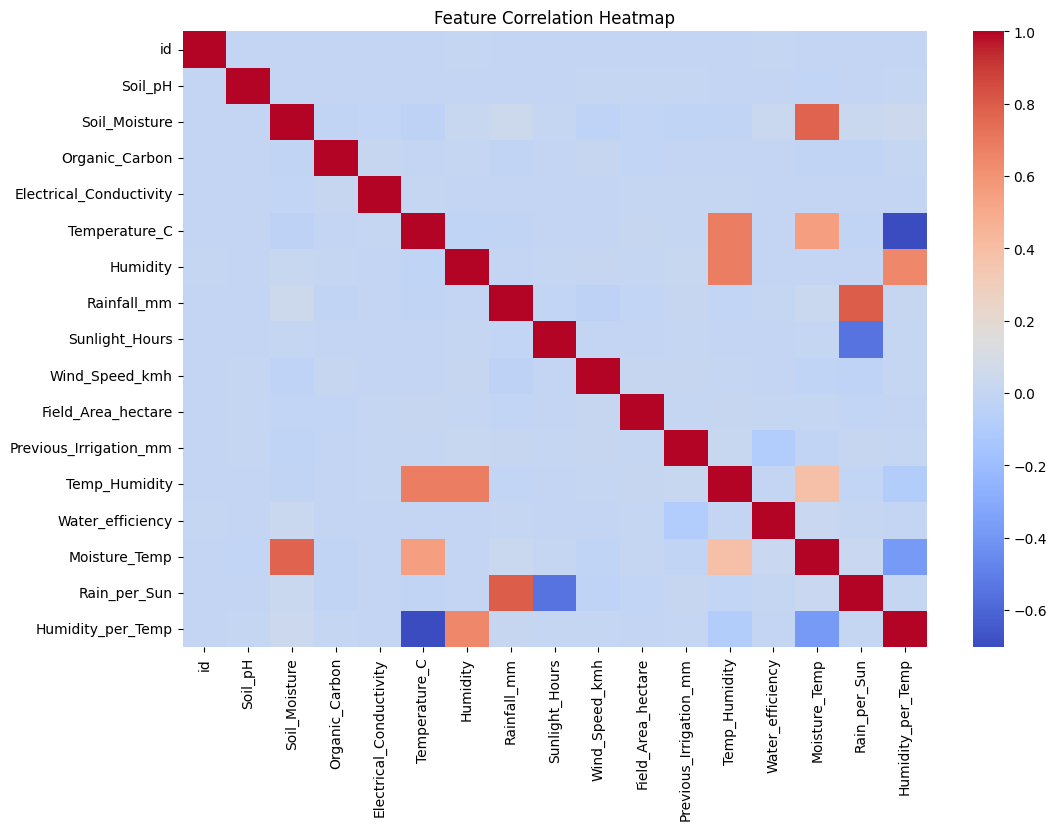

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

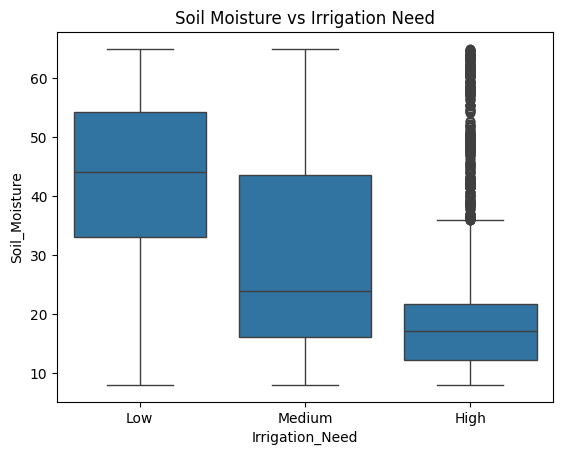

In [3]:
sns.boxplot(x=y, y=df['Soil_Moisture'])
plt.title("Soil Moisture vs Irrigation Need")
plt.show()

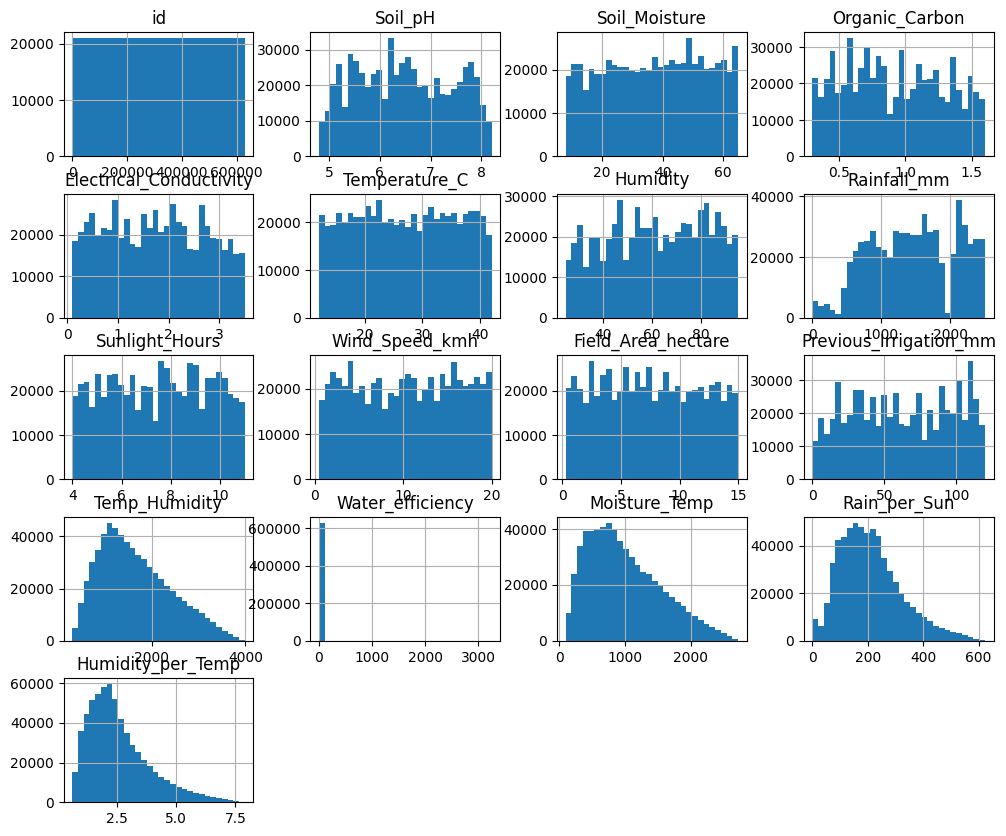

In [4]:
df.hist(figsize=(12,10), bins=30)
plt.show()

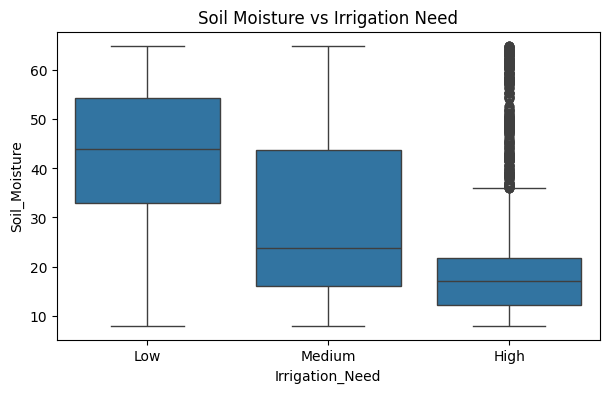

In [5]:
plt.figure(figsize=(7,4))
sns.boxplot(x=y, y=df['Soil_Moisture'])
plt.title("Soil Moisture vs Irrigation Need")
plt.show()

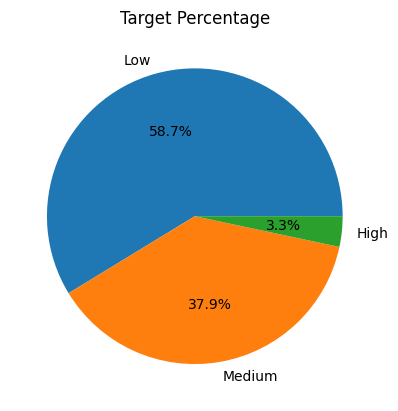

In [6]:
y.value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%')
plt.title("Target Percentage")
plt.ylabel("")
plt.show()

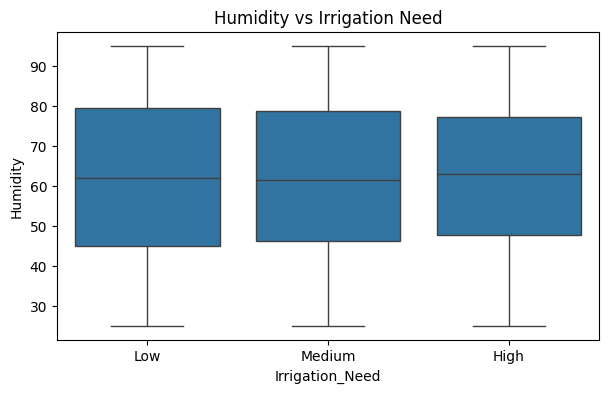

In [7]:
plt.figure(figsize=(7,4))
sns.boxplot(x=y, y=df['Humidity'])
plt.title("Humidity vs Irrigation Need")
plt.show()


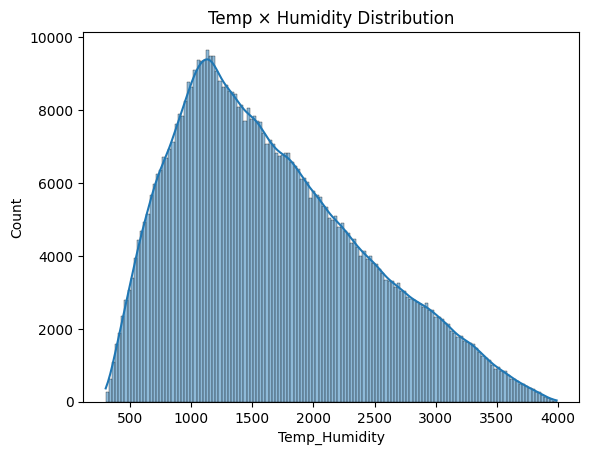

In [8]:
sns.histplot(df['Temp_Humidity'], kde=True)
plt.title("Temp × Humidity Distribution")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


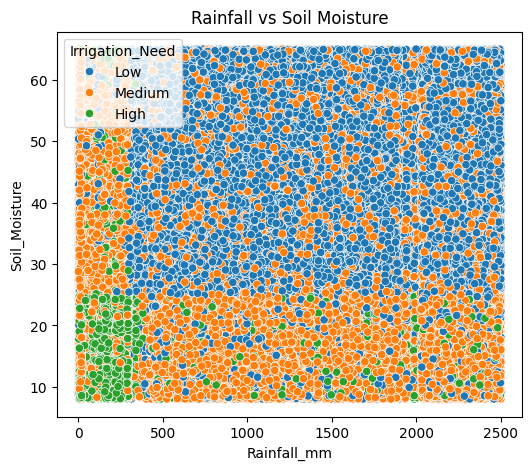

In [9]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df['Rainfall_mm'], y=df['Soil_Moisture'], hue=y)
plt.title("Rainfall vs Soil Moisture")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


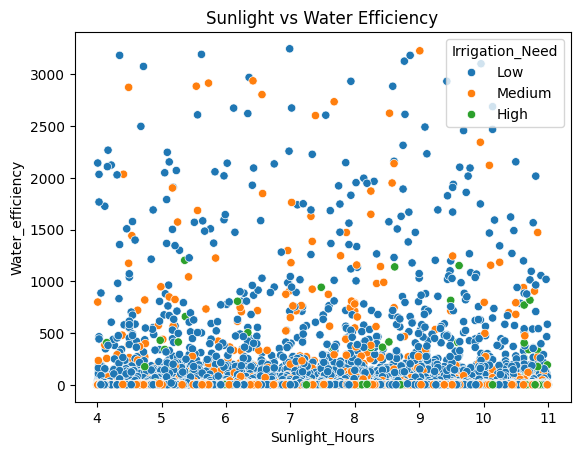

In [10]:
sns.scatterplot(x=df['Sunlight_Hours'], y=df['Water_efficiency'], hue=y)
plt.title("Sunlight vs Water Efficiency")
plt.show()

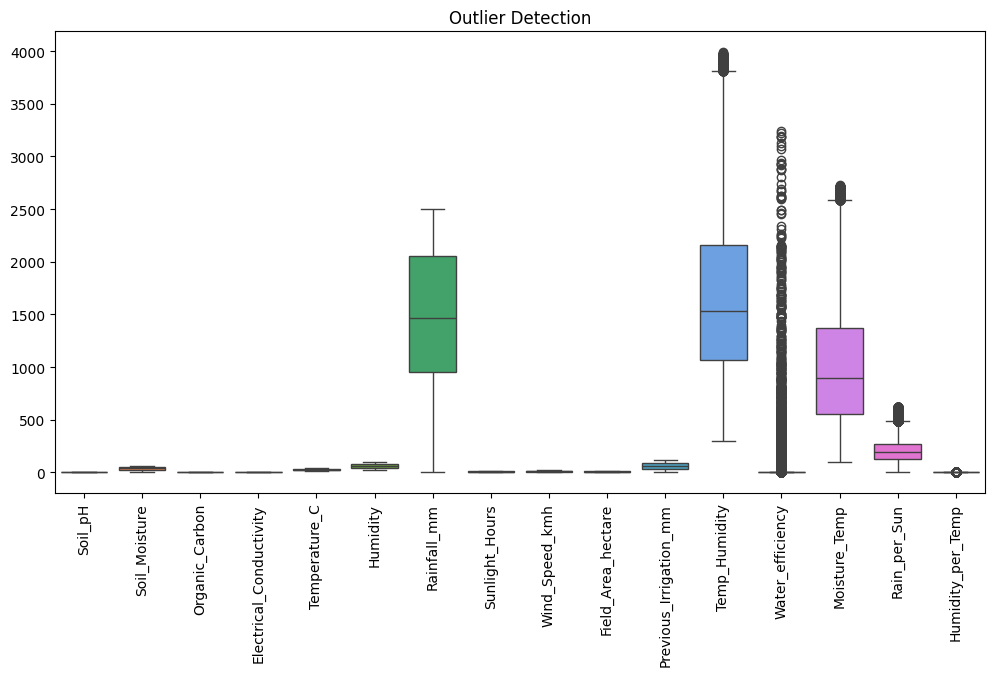

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()